# Predicting Credit Card Default Risk
## Final Capstone Project | Research-Style Data Science Report

**Dataset:** UCI Taiwan credit card clients

**Research question:** Can customer demographic, repayment-status, billing, and payment behavior predict whether a credit-card account will default in the following month?

This notebook follows a complete, reproducible workflow: problem definition, data understanding, cleaning, preprocessing, exploratory analysis, statistical testing, supervised model development, evaluation, findings, limitations, and recommendations.

## Executive Summary

This project develops and evaluates classification models for next-month credit-card default. The analysis emphasizes the minority default class, because a model that predicts every account as non-default can appear accurate while failing the business objective. Model selection therefore considers ROC-AUC, PR-AUC, balanced accuracy, recall, and precision alongside overall accuracy.

The results below are generated from the data when the notebook is executed. The final recommendations should be based on the measured validation performance, statistical tests, and operational trade-offs rather than accuracy alone.

In [1]:
# Reproducibility and imports
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, precision_score, recall_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

## 1. Problem Definition and Analytical Design

The target is `default.payment.next.month`, where 1 indicates default in the next month and 0 indicates no default. The prediction task is binary classification. The supplied `ID` field is an identifier, not a behavioral predictor, so it is excluded from modeling. All transformations are fitted inside scikit-learn pipelines to prevent information leakage from the validation data into training.

The primary business framing is risk screening: identify accounts with elevated default probability so that limited intervention resources can be prioritized. False negatives may be costly, but false positives also have customer and operational costs; threshold selection should therefore be made with a documented cost policy.

In [2]:
# Load the portable local copy; fall back to the supplied Downloads location if needed.
workspace_path = Path.cwd()
candidate_paths = [
    workspace_path / 'P_5_UCI_Credit_Card.csv',
    Path(r'C:/Users/rishi/Downloads/P_5_UCI_Credit_Card.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Place P_5_UCI_Credit_Card.csv beside this notebook or update candidate_paths.')

df = pd.read_csv(data_path)
target = 'default.payment.next.month'
if target not in df.columns:
    raise ValueError(f'Expected target {target!r}; found columns: {list(df.columns)}')

print(f'Loaded: {data_path.resolve()}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head())

Loaded: D:\Programming\IDRA\Capstone\P_5_UCI_Credit_Card.csv
Shape: 30,000 rows x 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,"20,000.000",2,2,1,24,2,2,-1,-1,-2,-2,"3,913.000","3,102.000",689.000,0.000,0.000,0.000,0.000,689.000,0.000,0.000,0.000,0.000,1
1,2,"120,000.000",2,2,2,26,-1,2,0,0,0,2,"2,682.000","1,725.000","2,682.000","3,272.000","3,455.000","3,261.000",0.000,"1,000.000","1,000.000","1,000.000",0.000,"2,000.000",1
2,3,"90,000.000",2,2,2,34,0,0,0,0,0,0,"29,239.000","14,027.000","13,559.000","14,331.000","14,948.000","15,549.000","1,518.000","1,500.000","1,000.000","1,000.000","1,000.000","5,000.000",0
3,4,"50,000.000",2,2,1,37,0,0,0,0,0,0,"46,990.000","48,233.000","49,291.000","28,314.000","28,959.000","29,547.000","2,000.000","2,019.000","1,200.000","1,100.000","1,069.000","1,000.000",0
4,5,"50,000.000",1,2,1,57,-1,0,-1,0,0,0,"8,617.000","5,670.000","35,835.000","20,940.000","19,146.000","19,131.000","2,000.000","36,681.000","10,000.000","9,000.000",689.000,679.000,0


## 2. Dataset Understanding and Data Quality

The dataset contains credit limits, demographic attributes, repayment-status history (`PAY_0` through `PAY_6`), six monthly bill amounts, six monthly payment amounts, and the next-month default outcome. The following checks document data types, missingness, duplicates, target prevalence, and unusual values before modeling.

In [3]:
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100),
    'unique_values': df.nunique(),
})
print(f'Duplicate rows: {df.duplicated().sum():,}')
display(profile)

target_counts = df[target].value_counts().sort_index()
target_summary = pd.DataFrame({'count': target_counts, 'percentage': target_counts / len(df) * 100})
display(target_summary)
print('Numeric summary:')
display(df.describe().T)

Duplicate rows: 0


,dtype,missing,missing_pct,unique_values
ID,int64,0,0.000,30000
LIMIT_BAL,float64,0,0.000,81
SEX,int64,0,0.000,2
EDUCATION,int64,0,0.000,7
MARRIAGE,int64,0,0.000,4
AGE,int64,0,0.000,56
PAY_0,int64,0,0.000,11
PAY_2,int64,0,0.000,11
PAY_3,int64,0,0.000,11
PAY_4,int64,0,0.000,11


,count,percentage
default.payment.next.month,,
0,23364,77.880
1,6636,22.120


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
ID,"30,000.000","15,000.500","8,660.398",1.000,"7,500.750","15,000.500","22,500.250","30,000.000"
LIMIT_BAL,"30,000.000","167,484.323","129,747.662","10,000.000","50,000.000","140,000.000","240,000.000","1,000,000.000"
SEX,"30,000.000",1.604,0.489,1.000,1.000,2.000,2.000,2.000
EDUCATION,"30,000.000",1.853,0.790,0.000,1.000,2.000,2.000,6.000
MARRIAGE,"30,000.000",1.552,0.522,0.000,1.000,2.000,2.000,3.000
AGE,"30,000.000",35.486,9.218,21.000,28.000,34.000,41.000,79.000
PAY_0,"30,000.000",-0.017,1.124,-2.000,-1.000,0.000,0.000,8.000
PAY_2,"30,000.000",-0.134,1.197,-2.000,-1.000,0.000,0.000,8.000
PAY_3,"30,000.000",-0.166,1.197,-2.000,-1.000,0.000,0.000,8.000
PAY_4,"30,000.000",-0.221,1.169,-2.000,-1.000,0.000,0.000,8.000


In [4]:
# Cleaning decisions are explicit and reproducible.
clean_df = df.copy()
clean_df.columns = clean_df.columns.str.strip()
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

# The ID is retained for auditability but excluded from predictors.
id_columns = [column for column in ['ID', 'id', 'Id'] if column in clean_df.columns]
feature_columns = [column for column in clean_df.columns if column not in id_columns + [target]]
X = clean_df[feature_columns].copy()
y = clean_df[target].astype(int).copy()

# Dataset-specific categorical codes. These are encoded rather than treated as continuous magnitudes.
categorical_candidates = ['SEX', 'EDUCATION', 'MARRIAGE']
categorical_features = [column for column in categorical_candidates if column in X.columns]
numeric_features = [column for column in X.columns if column not in categorical_features]
print(f'Rows after duplicate removal: {len(clean_df):,}')
print(f'Excluded identifier columns: {id_columns or "none"}')
print(f'Categorical predictors: {categorical_features}')
print(f'Numeric predictors: {len(numeric_features)}')

Rows after duplicate removal: 30,000
Excluded identifier columns: ['ID']
Categorical predictors: ['SEX', 'EDUCATION', 'MARRIAGE']
Numeric predictors: 20


## 3. Exploratory Data Analysis

The plots below examine target imbalance, demographic relationships, repayment behavior, and financial magnitudes. EDA is descriptive: it helps generate hypotheses, but it does not by itself establish causal relationships.

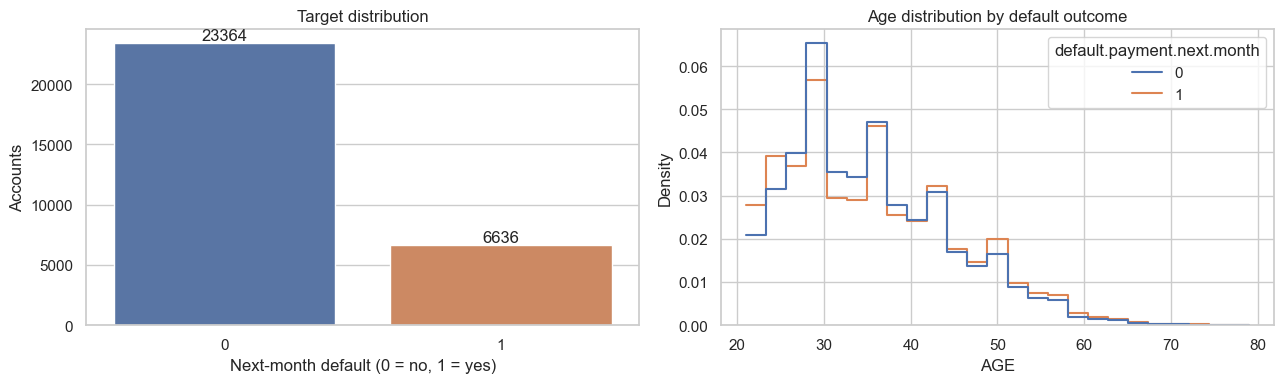

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=clean_df, x=target, ax=axes[0])
axes[0].set_title('Target distribution')
axes[0].set_xlabel('Next-month default (0 = no, 1 = yes)')
axes[0].set_ylabel('Accounts')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

if 'AGE' in clean_df and target in clean_df:
    sns.histplot(data=clean_df, x='AGE', hue=target, bins=25, stat='density', common_norm=False,
                 element='step', fill=False, ax=axes[1])
    axes[1].set_title('Age distribution by default outcome')
plt.tight_layout()
plt.show()

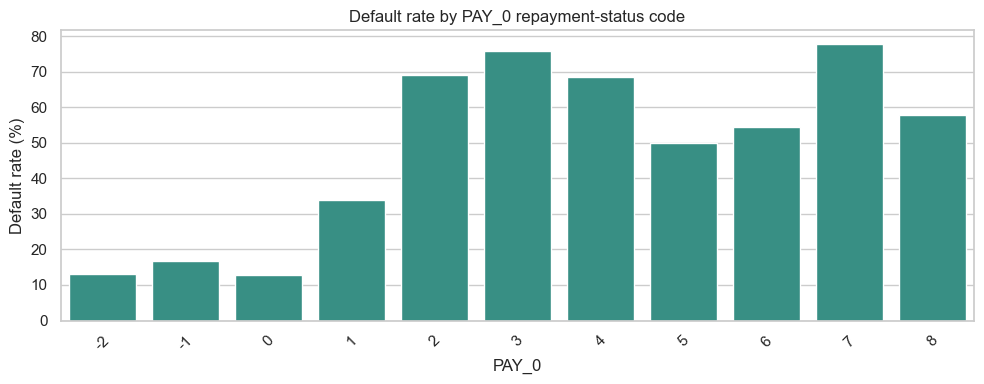

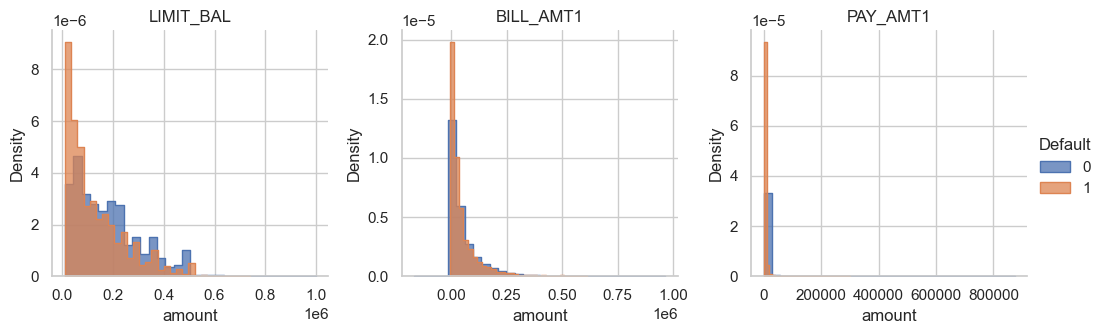

In [6]:
repayment_columns = [column for column in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'] if column in clean_df]
if repayment_columns:
    repayment_rates = clean_df.groupby(repayment_columns[0])[target].mean().sort_index().mul(100)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=repayment_rates.index.astype(str), y=repayment_rates.values, color='#2a9d8f')
    plt.title(f'Default rate by {repayment_columns[0]} repayment-status code')
    plt.xlabel(repayment_columns[0])
    plt.ylabel('Default rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

amount_columns = [column for column in ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1'] if column in clean_df]
if amount_columns:
    plot_data = clean_df[amount_columns + [target]].melt(id_vars=target, var_name='measure', value_name='amount')
    g = sns.FacetGrid(plot_data, col='measure', hue=target, col_wrap=3, height=3.5, sharex=False, sharey=False)
    g.map_dataframe(sns.histplot, x='amount', bins=30, element='step', stat='density', common_norm=False)
    g.add_legend(title='Default')
    g.set_titles('{col_name}')
    plt.show()

,default.payment.next.month
default.payment.next.month,1.000
PAY_0,0.325
PAY_2,0.264
PAY_3,0.235
PAY_4,0.217
PAY_5,0.204
PAY_6,0.187
EDUCATION,0.028
AGE,0.014
BILL_AMT6,-0.005


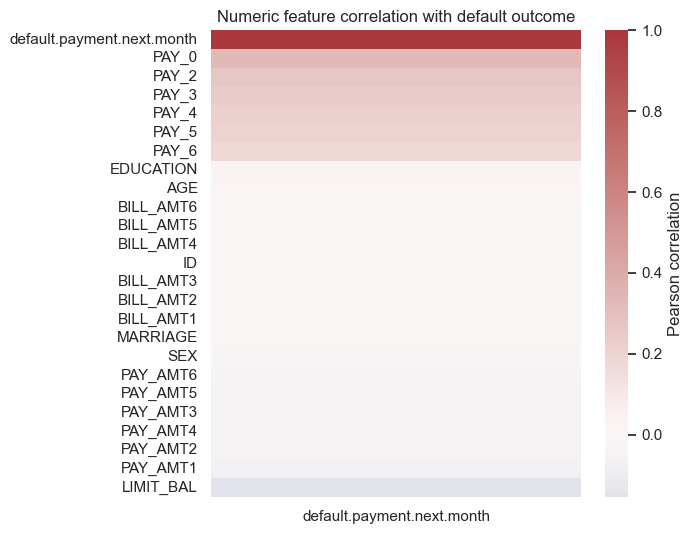

In [7]:
# Correlations are displayed for numeric variables only; they are not causal estimates.
numeric_eda = clean_df.select_dtypes(include=np.number)
corr = numeric_eda.corr(numeric_only=True)[[target]].sort_values(target, ascending=False)
display(corr.head(12))

plt.figure(figsize=(7, max(5, len(corr) * 0.22)))
sns.heatmap(corr, annot=False, cmap='vlag', center=0, cbar_kws={'label': 'Pearson correlation'})
plt.title('Numeric feature correlation with default outcome')
plt.tight_layout()
plt.show()

## 4. Statistical Analysis

Two complementary hypothesis tests are used. A chi-square test assesses whether a categorical predictor and default outcome are statistically independent. A Mann-Whitney U test compares the distribution of a skewed continuous financial variable between default groups without requiring normality. Statistical significance is evaluated at $\alpha = 0.05$, while practical effect size and predictive validation remain essential.

In [8]:
# Chi-square tests for selected categorical predictors
chi_square_rows = []
for column in categorical_features:
    table = pd.crosstab(clean_df[column], clean_df[target])
    statistic, p_value, degrees_freedom, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    cramers_v = np.sqrt((statistic / n) / max(1, min(table.shape) - 1))
    chi_square_rows.append({'feature': column, 'chi2': statistic, 'df': degrees_freedom,
                           'p_value': p_value, 'cramers_v': cramers_v})
chi_square_results = pd.DataFrame(chi_square_rows).sort_values('p_value')
display(chi_square_results)

# Mann-Whitney U tests for representative numeric variables
test_variables = [column for column in ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0'] if column in clean_df]
mw_rows = []
for column in test_variables:
    no_default = clean_df.loc[clean_df[target] == 0, column].dropna()
    default = clean_df.loc[clean_df[target] == 1, column].dropna()
    statistic, p_value = mannwhitneyu(no_default, default, alternative='two-sided')
    mw_rows.append({'feature': column, 'median_no_default': no_default.median(),
                    'median_default': default.median(), 'u_statistic': statistic, 'p_value': p_value})
mann_whitney_results = pd.DataFrame(mw_rows).sort_values('p_value')
display(mann_whitney_results)

,feature,chi2,df,p_value,cramers_v
1,EDUCATION,163.217,6,0.000,0.074
0,SEX,47.709,1,0.000,0.040
2,MARRIAGE,35.662,3,0.000,0.034


,feature,median_no_default,median_default,u_statistic,p_value
4,PAY_0,0.000,1.000,"48,108,422.500",0.000
0,LIMIT_BAL,"150,000.000","90,000.000","95,786,286.500",0.000
3,PAY_AMT1,"2,459.500","1,636.000","94,780,733.000",0.000
2,BILL_AMT1,"23,119.500","20,185.000","80,252,445.500",0.000
1,AGE,34.000,34.000,"76,966,879.500",0.373


## 5. Preprocessing and Model Development

A stratified train/test split preserves the outcome ratio. Numeric variables use median imputation and standardization for the linear model. Categorical variables use most-frequent imputation and one-hot encoding. Tree models use the same safe imputation and one-hot representation; all transformations are fitted only on training folds through pipelines.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features),
])

models = {
    'Dummy majority baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random forest': RandomForestClassifier(n_estimators=250, min_samples_leaf=3, class_weight='balanced',
                                           n_jobs=-1, random_state=RANDOM_STATE),
    'Hist-gradient boosting': HistGradientBoostingClassifier(max_iter=200, learning_rate=0.08,
                                                              max_leaf_nodes=31, random_state=RANDOM_STATE),
}
pipelines = {name: Pipeline([('preprocess', preprocessor), ('model', model)])
            for name, model in models.items()}

print(f'Train rows: {len(X_train):,}; test rows: {len(X_test):,}')
print(f'Train default rate: {y_train.mean():.2%}; test default rate: {y_test.mean():.2%}')

Train rows: 24,000; test rows: 6,000
Train default rate: 22.12%; test default rate: 22.12%


## 6. Cross-Validated Model Evaluation

Five-fold stratified cross-validation estimates out-of-sample performance on the training set. ROC-AUC measures ranking across thresholds, while PR-AUC is particularly informative when the positive class is less common. Balanced accuracy gives equal weight to sensitivity and specificity.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision', 'balanced_accuracy': 'balanced_accuracy',
           'accuracy': 'accuracy', 'recall': 'recall', 'precision': 'precision'}
cv_rows = []
for name, pipeline in pipelines.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'model': name}
    for metric in scoring:
        row[f'{metric}_mean'] = scores[f'test_{metric}'].mean()
        row[f'{metric}_std'] = scores[f'test_{metric}'].std()
    cv_rows.append(row)
cv_results = pd.DataFrame(cv_rows).sort_values('pr_auc_mean', ascending=False)
display(cv_results.style.format({column: '{:.3f}' for column in cv_results.columns if column != 'model'}))

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,recall_mean,recall_std,precision_mean,precision_std
3,Hist-gradient boosting,0.782,0.003,0.562,0.007,0.660,0.004,0.822,0.002,0.370,0.008,0.677,0.011
2,Random forest,0.780,0.004,0.552,0.008,0.694,0.004,0.811,0.003,0.484,0.007,0.588,0.008
1,Logistic regression,0.727,0.011,0.505,0.013,0.675,0.010,0.689,0.010,0.651,0.017,0.381,0.011
0,Dummy majority baseline,0.500,0.000,0.221,0.000,0.500,0.000,0.779,0.000,0.000,0.000,0.000,0.000


In [11]:
# Fit every model on the full training split and evaluate the untouched test split.
fitted_models = {}
test_rows = []
for name, pipeline in pipelines.items():
    fitted = clone(pipeline).fit(X_train, y_train)
    fitted_models[name] = fitted
    predictions = fitted.predict(X_test)
    probabilities = fitted.predict_proba(X_test)[:, 1] if hasattr(fitted, 'predict_proba') else fitted.decision_function(X_test)
    test_rows.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, probabilities),
        'pr_auc': average_precision_score(y_test, probabilities),
        'balanced_accuracy': balanced_accuracy_score(y_test, predictions),
        'accuracy': accuracy_score(y_test, predictions),
        'recall': recall_score(y_test, predictions, zero_division=0),
        'precision': precision_score(y_test, predictions, zero_division=0),
    })
test_results = pd.DataFrame(test_rows).sort_values('pr_auc', ascending=False)
display(test_results.style.format({column: '{:.3f}' for column in test_results.columns if column != 'model'}))

best_name = test_results.iloc[0]['model']
best_model = fitted_models[best_name]
best_predictions = best_model.predict(X_test)
best_probabilities = best_model.predict_proba(X_test)[:, 1]
print(f'Best model by test PR-AUC: {best_name}')
print(classification_report(y_test, best_predictions, target_names=['No default', 'Default'], zero_division=0))

,model,roc_auc,pr_auc,balanced_accuracy,accuracy,recall,precision
3,Hist-gradient boosting,0.777,0.549,0.656,0.818,0.366,0.660
2,Random forest,0.768,0.547,0.690,0.808,0.480,0.579
1,Logistic regression,0.711,0.491,0.662,0.678,0.632,0.368
0,Dummy majority baseline,0.500,0.221,0.500,0.779,0.000,0.000


Best model by test PR-AUC: Hist-gradient boosting
              precision    recall  f1-score   support

  No default       0.84      0.95      0.89      4673
     Default       0.66      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



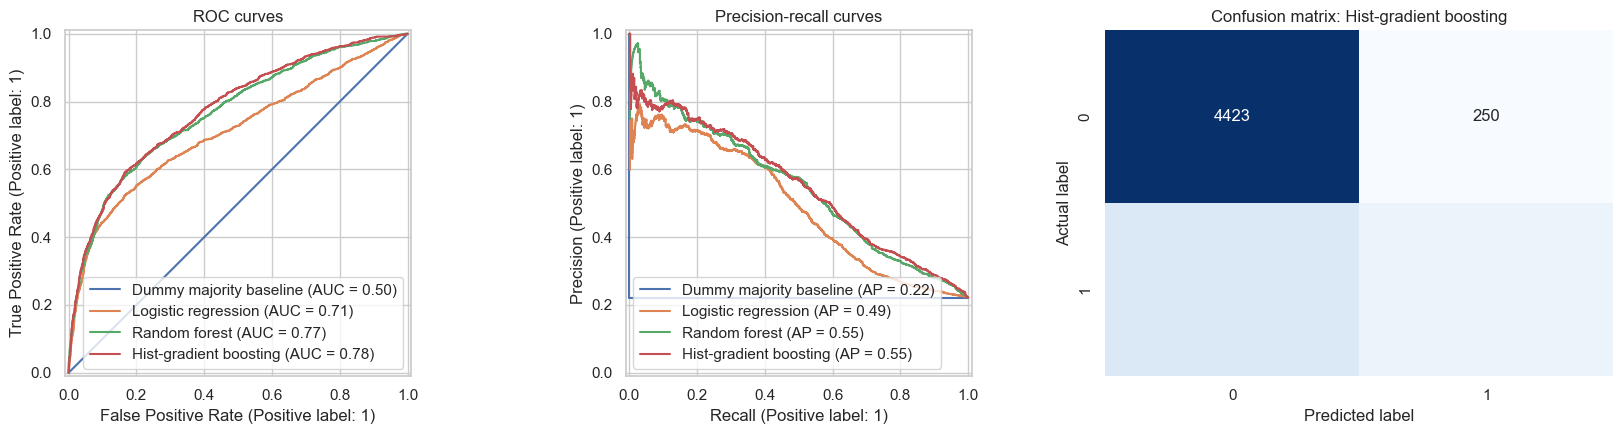

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for name, pipeline in fitted_models.items():
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, probabilities, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, probabilities, name=name, ax=axes[1])
sns.heatmap(confusion_matrix(y_test, best_predictions), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2])
axes[2].set_title(f'Confusion matrix: {best_name}')
axes[2].set_xlabel('Predicted label')
axes[2].set_ylabel('Actual label')
axes[0].set_title('ROC curves')
axes[1].set_title('Precision-recall curves')
plt.tight_layout()
plt.show()

## 7. Model Interpretation

Permutation importance measures the decrease in a chosen validation score when a feature is randomly shuffled. It is model-agnostic and is reported on the untouched test set. Importance is predictive contribution, not causal influence.

,mean_pr_auc_decrease
PAY_0,0.197
BILL_AMT1,0.016
LIMIT_BAL,0.011
BILL_AMT6,0.007
PAY_AMT1,0.007
PAY_6,0.007
PAY_AMT2,0.006
PAY_2,0.006
PAY_AMT3,0.006
BILL_AMT3,0.005


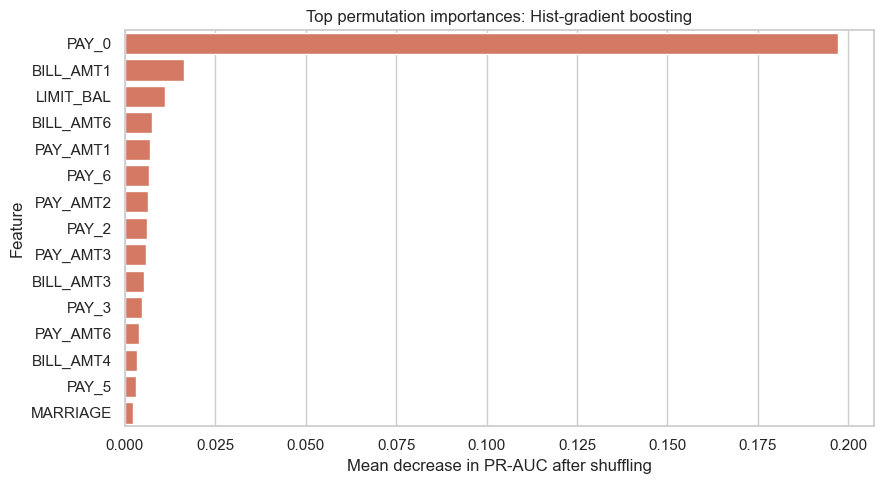

In [13]:
permutation = permutation_importance(best_model, X_test, y_test, scoring='average_precision',
                                     n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(permutation.importances_mean, index=X_test.columns).sort_values(ascending=False)
display(importance.head(15).to_frame('mean_pr_auc_decrease'))

plt.figure(figsize=(9, 5))
sns.barplot(x=importance.head(15).values, y=importance.head(15).index, color='#e76f51')
plt.title(f'Top permutation importances: {best_name}')
plt.xlabel('Mean decrease in PR-AUC after shuffling')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Findings, Recommendations, and Limitations

### Findings

The executed tables and figures provide the evidence for the final findings. In particular, compare the best model against the majority baseline, inspect PR-AUC and recall for the default class, review the confusion matrix, and connect the strongest permutation features with the repayment-history EDA.

### Recommendations

1. Use the selected model as a prioritization tool, not as an automatic adverse-action decision.
2. Choose an operating probability threshold using an explicit business cost matrix for missed defaults versus unnecessary interventions.
3. Monitor recall, precision, PR-AUC, calibration, and subgroup performance over time; retrain if portfolio behavior shifts.
4. Review the strongest behavioral predictors with credit-risk and compliance stakeholders before operational deployment.
5. Add probability calibration, fairness checks, and temporal validation before production use.

### Limitations

This is observational cross-sectional data, so predictive associations should not be interpreted causally. The random split may be optimistic if deployment data are time-dependent. The dataset's category codes may contain unusual or undocumented values, and no external economic variables are included. Thresholds were not optimized to a stated financial cost function.

## Conclusion

This project demonstrates an end-to-end credit-default classification workflow. It documents the data, handles identifiers and mixed feature types, prevents preprocessing leakage with pipelines, quantifies imbalance, applies statistical tests, compares baseline and nonlinear models, evaluates ranking and class-specific performance, and interprets the selected model. The most defensible operational conclusion should be drawn from the executed test metrics and the cost-sensitive threshold policy adopted by the business.

### Exporting the report to PDF

After running all cells, use **File > Export Notebook As > PDF** in VS Code, or run `jupyter nbconvert --to webpdf credit_card_default_capstone.ipynb` from the project folder. If LaTeX is installed, `jupyter nbconvert --to pdf credit_card_default_capstone.ipynb` is another option.

Validation-selected cutoff maximizing F2: 0.12


,cutoff,test_precision,test_recall,test_balanced_accuracy
0,0.500,0.660,0.366,0.656
1,0.120,0.309,0.859,0.657


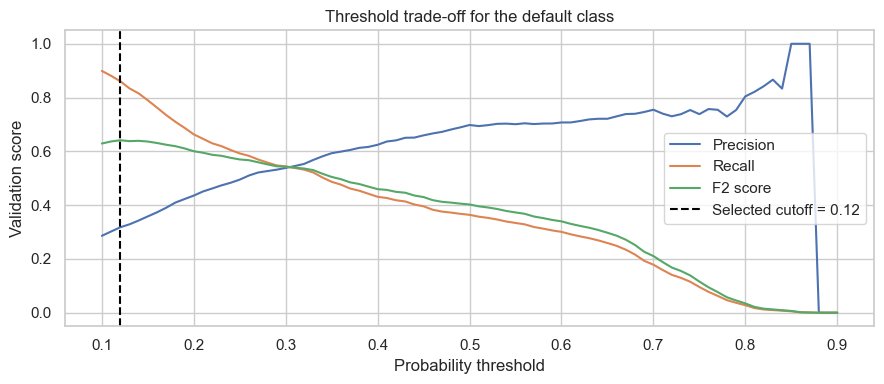

In [14]:
# Threshold analysis: choose an operating cutoff from a validation split, then evaluate it on the test set.
from sklearn.metrics import precision_recall_curve

X_fit, X_validation, y_fit, y_validation = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)
threshold_model = clone(best_model).fit(X_fit, y_fit)
validation_probabilities = threshold_model.predict_proba(X_validation)[:, 1]
test_probabilities = best_model.predict_proba(X_test)[:, 1]

threshold_grid = np.linspace(0.10, 0.90, 81)
threshold_rows = []
for threshold in threshold_grid:
    validation_predictions = (validation_probabilities >= threshold).astype(int)
    precision = precision_score(y_validation, validation_predictions, zero_division=0)
    recall = recall_score(y_validation, validation_predictions, zero_division=0)
    f2 = (5 * precision * recall / (4 * precision + recall)) if (precision + recall) else 0
    threshold_rows.append({'threshold': threshold, 'precision': precision, 'recall': recall, 'f2_score': f2})

threshold_results = pd.DataFrame(threshold_rows)
best_threshold = threshold_results.loc[threshold_results['f2_score'].idxmax(), 'threshold']
test_threshold_predictions = (test_probabilities >= best_threshold).astype(int)

threshold_comparison = pd.DataFrame([
    {
        'cutoff': 0.50,
        'test_precision': precision_score(y_test, (test_probabilities >= 0.50).astype(int), zero_division=0),
        'test_recall': recall_score(y_test, (test_probabilities >= 0.50).astype(int), zero_division=0),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, (test_probabilities >= 0.50).astype(int)),
    },
    {
        'cutoff': best_threshold,
        'test_precision': precision_score(y_test, test_threshold_predictions, zero_division=0),
        'test_recall': recall_score(y_test, test_threshold_predictions, zero_division=0),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, test_threshold_predictions),
    },
])
print(f'Validation-selected cutoff maximizing F2: {best_threshold:.2f}')
display(threshold_comparison)

plt.figure(figsize=(9, 4))
plt.plot(threshold_results['threshold'], threshold_results['precision'], label='Precision')
plt.plot(threshold_results['threshold'], threshold_results['recall'], label='Recall')
plt.plot(threshold_results['threshold'], threshold_results['f2_score'], label='F2 score')
plt.axvline(best_threshold, color='black', linestyle='--', label=f'Selected cutoff = {best_threshold:.2f}')
plt.xlabel('Probability threshold')
plt.ylabel('Validation score')
plt.title('Threshold trade-off for the default class')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Final workflow completeness audit
# These assertions make the required capstone stages executable and easy to verify.
workflow_checks = {
    'data_loaded': isinstance(df, pd.DataFrame) and not df.empty,
    'data_cleaned': isinstance(clean_df, pd.DataFrame) and len(clean_df) <= len(df),
    'preprocessing_defined': isinstance(preprocessor, ColumnTransformer),
    'eda_completed': 'corr' in globals() and isinstance(corr, pd.DataFrame),
    'statistical_analysis_completed': 'chi_square_results' in globals() and 'mann_whitney_results' in globals(),
    'visualizations_created': all(name in globals() for name in ['target_counts', 'repayment_rates', 'corr']),
    'models_developed': len(fitted_models) >= 3,
    'model_evaluation_completed': isinstance(cv_results, pd.DataFrame) and isinstance(test_results, pd.DataFrame),
}
assert all(workflow_checks.values()), workflow_checks
workflow_status = pd.DataFrame({'stage': list(workflow_checks), 'completed': list(workflow_checks.values())})
display(workflow_status)
print('All required data-science workflow stages are present and completed.')

,stage,completed
0,data_loaded,True
1,data_cleaned,True
2,preprocessing_defined,True
3,eda_completed,True
4,statistical_analysis_completed,True
5,visualizations_created,True
6,models_developed,True
7,model_evaluation_completed,True


All required data-science workflow stages are present and completed.
